<a href="https://colab.research.google.com/github/adityaghai07/ag-yt-lectures/blob/main/vector_addition_kernel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import triton
import triton.language as tl
import numpy as np

In [2]:
# do an add kernel
# test
# benchmark the created kernel

In [3]:
!nvidia-smi

Sat May 16 07:48:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
device = torch.device("cuda")
device

device(type='cuda')

In [5]:
@triton.jit
def add_kernel(
    x_ptr,
    y_ptr,
    output_ptr,
    BLOCK_SIZE: tl.constexpr,
    num_elements
):

  pid = tl.program_id(axis=0)

  block_start = pid*BLOCK_SIZE
  offsets = block_start + tl.arange(0, BLOCK_SIZE)

  mask = offsets < num_elements

  x = tl.load(x_ptr + offsets, mask = mask)
  y = tl.load(y_ptr + offsets, mask = mask)


  output =  x + y

  tl.store(output_ptr + offsets, output, mask = mask)


In [6]:
def add(x, y):
  # allocate space to my output
  out = torch.empty_like(y)

  # assert x.device == y.device == out.device == device


  n_elements = x.numel()
  BLOCK_SIZE = 1024

  grid = lambda meta : (triton.cdiv(n_elements, meta['BLOCK_SIZE']),)   # (x,)


  add_kernel[grid](
      x,
      y,
      out,
      BLOCK_SIZE = BLOCK_SIZE,
      num_elements = n_elements
  )


  return out



In [7]:
def test_add_kernel(size, atol=1e-4, rtol=1e-4, device=device):
  torch.manual_seed(7)
  x = torch.randn(size, device='cuda')
  y = torch.randn(size, device='cuda')

  out_py = x + y
  out_tri = add(x, y)

  torch.testing.assert_allclose(out_py, out_tri, atol=atol, rtol=rtol)
  print("yaaaaaay!")

In [8]:
test_add_kernel(4096)
test_add_kernel(1000000)

yaaaaaay!
yaaaaaay!


/tmp/ipykernel_4227/2022268980.py:9: FutureWarning: `torch.testing.assert_allclose()` is deprecated since 1.12 and will be removed in a future release. Please use `torch.testing.assert_close()` instead. You can find detailed upgrade instructions in https://github.com/pytorch/pytorch/issues/61844.
  torch.testing.assert_allclose(out_py, out_tri, atol=atol, rtol=rtol)


vector-add-performance:
          size  Triton (GB/s)  PyTorch (torch.add) (GB/s)
0       4096.0       7.279621                    7.144186
1       8192.0      15.593909                   21.259515
2      16384.0      37.693252                   37.925925
3      32768.0      63.999998                   64.335079
4      65536.0      99.096776                   96.946742
5     131072.0     145.851630                  145.851630
6     262144.0     182.044451                  182.721182
7     524288.0     205.872252                  204.800005
8    1048576.0     219.428568                  219.428568
9    2097152.0     228.613961                  228.946720
10   4194304.0     234.057145                  234.057145
11   8388608.0     236.805788                  237.270178
12  16777216.0     239.925865                  240.365855
13  33554432.0     241.830252                  241.663062


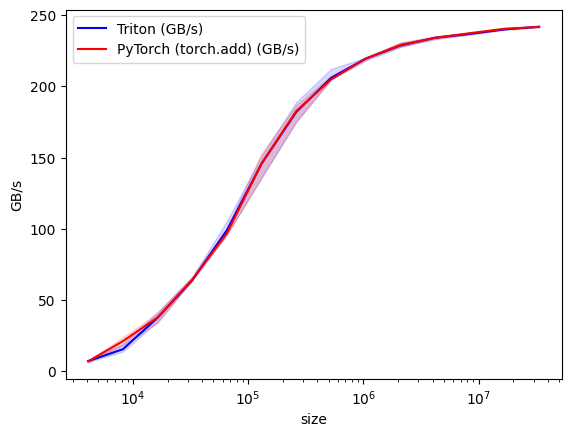

In [16]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=['size'],                                    # x-axis param name
        x_vals=[2**i for i in range(12, 26, 1)],            # 4K to 32M elements
        x_log=True,                                          # log-scale x-axis
        line_arg='provider',                                 # what creates separate lines
        line_vals=['triton', 'torch'],                       # one line each
        line_names=['Triton', 'PyTorch (torch.add)'],        # legend labels
        styles=[('blue', '-'), ('red', '-')],                # line colors & styles
        ylabel='GB/s',                                       # y-axis label
        plot_name='vector-add-performance',                  # chart title & filename
        args={},                                             # extra fixed args (none here)
    )
)
def benchmark(size, provider):

    x = torch.randn(size, device='cuda', dtype=torch.float32)
    y = torch.randn(size, device='cuda', dtype=torch.float32)

    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: add(x, y),
            quantiles=[0.5, 0.2, 0.8],   # median, 20th, 80th percentile
        )
    else:  # 'torch'
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: x + y,
            quantiles=[0.5, 0.2, 0.8],
        )

    gbps = lambda ms: 3 * size * x.element_size() / ms * 1e-6
    return gbps(ms), gbps(max_ms), gbps(min_ms)


benchmark.run(save_path='.', print_data=True)


In [ ]:
# vector add is memory bound :)